In [166]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from pfns.bar_distribution import FullSupportBarDistribution
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
from tabpfn_time_series import (
    FeatureTransformer,
    TabPFNMode,
    TabPFNTimeSeriesPredictor,
    TabPFNTSPipeline,
    TimeSeriesDataFrame,
)
from tabpfn_time_series.features import (
    AutoSeasonalFeature,
    CalendarFeature,
    RunningIndexFeature,
)
from tabpfn_time_series.plot import plot_forecast
from tqdm import tqdm

from tfmplayground import NanoTabPFNClassifier, NanoTabPFNRegressor
from tfmplayground.models.nanotabpfn import NanoTabPFNModel

In [167]:
DATAPATH = "/data/PFN/Mouse/"
FILE = "data_v6.csv"
TRAILS = [3]
NUM_ANIMALS = 4000
NUM_TEST_ANIMALS = 4000
PREDICTION_LENGTH = 2
MIN_LENGTH = 5
MAX_WEIGHT = 100
ROLES = [1, 2, 3]

os.environ["TABPFN_TOKEN"] = "tabpfn_sk_3XA36olToOXSzenBDBSzotxkWIoad2auFJauzRmtfjI"

## Prepare data

### Read data

In [168]:
df = pd.read_csv(os.path.join(DATAPATH, FILE))

print(df.columns)

# df = df[df["Versuchsreihe"].isin(VERSUCHSREIHE)].drop(columns=["Versuchsreihe"]).reset_index(drop=True)
print(f"Rows before trails filer: {len(df)}")
df = df[df["trail"].isin(TRAILS)].reset_index(drop=True)
print(f"Rows after trails filer: {len(df)}")

# Remove irrelevant roles
print(f"Rows before roles filer: {len(df)}")
df = df[df["role"].isin(ROLES)].reset_index(drop=True)
print(f"Rows after roles filer: {len(df)}")

# Filter animals that have less than MIN_LENGTH measurements
print(f"Rows before min length filer: {len(df)}")
df = df.groupby("id").filter(lambda x: len(x) >= MIN_LENGTH).reset_index(drop=True)
print(f"Rows after min length filer: {len(df)}")

# Filter animals that have values that are not possible < 0 or > MAX_WEIGHT
print(f"Rows before normal weight filer: {len(df)}")
df = df.groupby("id").filter(lambda x: (x["weight"] > 0).all() and (x["weight"] < MAX_WEIGHT).all()).reset_index(drop=True)
print(f"Rows after normal weight filer: {len(df)}")

# Minimum of one intervention
print(f"Rows before min intervention filer: {len(df)}")
df = df.groupby("id").filter(lambda x: (x["intervention"] > 0).any()).reset_index(drop=True)
print(f"Rows after min intervention filer: {len(df)}")

# df["id"] = df["id"].astype("category").cat.codes.astype(int)

# Limit df to NUM_SERIES animals for now
NUM_ANIMALS = min(NUM_ANIMALS, df["id"].nunique())
selected_ids = np.random.choice(df["id"].unique(), size=NUM_ANIMALS, replace=False)
df = df[df["id"].isin(selected_ids)].reset_index(drop=True)

# Ensure it is sorted
df = df.sort_values(["id", "date"]).reset_index(drop=True)

# Rename to item_id, timestamp, target
df = df.rename(columns={"id": "item_id", "date": "timestamp", "weight": "target"})

therapy_types = {
    0: "No treatment",
    1: "Radiotherapy",
    2: "Radio- and chemotherapy",
    3: "Chemotherapy",
    4: "Surgery"
}

info_df = df.groupby("item_id").nth(0).reset_index()[["item_id", "trail", "role"]]
info_df["type"] = info_df["role"]

df

Index(['id', 'date', 'time', 'weight', 'radio', 'chemo', 'intervention',
       'trail', 'role'],
      dtype='object')
Rows before trails filer: 21767
Rows after trails filer: 7015
Rows before roles filer: 7015
Rows after roles filer: 3110
Rows before min length filer: 3110
Rows after min length filer: 3110
Rows before normal weight filer: 3110
Rows after normal weight filer: 3084
Rows before min intervention filer: 3084
Rows after min intervention filer: 3084


,item_id,timestamp,time,target,radio,chemo,intervention,trail,role
0,3,2013-06-17,09:30:00,26.7,0,0,0,3,1
1,3,2013-06-24,15:00:00,27.0,0,0,0,3,1
2,3,2013-06-27,10:15:00,27.2,0,0,0,3,1
3,3,2013-07-01,08:30:00,27.3,0,0,0,3,1
4,3,2013-07-05,17:50:00,27.1,0,0,0,3,1
...,...,...,...,...,...,...,...,...,...
3079,437,2016-06-16,08:14:00,16.7,0,0,0,3,1
3080,437,2016-06-17,07:51:00,16.8,0,0,0,3,1
3081,437,2016-06-18,11:44:00,16.9,0,0,0,3,1
3082,437,2016-06-19,14:12:00,16.6,0,0,0,3,1


In [169]:
# # TEMPORARY: Filter out animals with less than X measurements
# df = df.groupby("item_id").filter(lambda x: len(x) >= 20).reset_index(drop=True)

# # And have atleast one intervention
# df = df.groupby("item_id").filter(lambda x: (x["Intervention"] == 1).any()).reset_index(drop=True)

In [170]:
# df = pd.read_csv(os.path.join(DATAPATH, FILE))
# info_df = df.groupby("id").nth(0).reset_index()[["id", "trail", "role"]]
# info_df = info_df.rename(columns={
#     "id": "mouse_id"
# })

# df = pd.read_pickle("/data/marina/features-with-indicators.pkl")
# df["intervention"] = (df["chemo"] + df["radiation"]).clip(upper=1)
# df = df.merge(info_df[["mouse_id", "role"]], on="mouse_id", how="left")
# df = df.rename(columns={
#     "mouse_id": "item_id",
#     "date": "timestamp",
#     "weight": "target",
#     "radiation": "radio",
# })
# df = df[["item_id", "timestamp", "target", "radio", "chemo", "intervention", "days_since", "trail", "role"]]

# # Only 
# df = df[df["trail"].isin(TRAILS)]

# info_df = info_df.rename(columns={
#     "mouse_id": "item_id"
# })
# info_df["type"] = info_df["role"]

# df

### Preprocess data

In [171]:
# Take last PREDICTION_LENGTH rows as test_df, rest as context_df
NUM_TEST_ANIMALS = min(NUM_TEST_ANIMALS, df["item_id"].nunique())
selected_ids = np.random.choice(df["item_id"].unique(), size=NUM_TEST_ANIMALS, replace=False)
test_df = df[df["item_id"].isin(selected_ids)].groupby("item_id").tail(PREDICTION_LENGTH)
# test_df = df.groupby("item_id").tail(PREDICTION_LENGTH)
context_df = df.drop(test_df.index)
future_df = test_df.drop(columns=["target"]).copy()

# Reset index for all DataFrames
context_df = context_df.reset_index(drop=True)
future_df = future_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# Copy item_id as new column "IdTier"
context_df["id"] = context_df["item_id"]
future_df["id"] = future_df["item_id"]
test_df["id"] = test_df["item_id"]

print(f"Columns: {context_df.columns}")


base_columns = ["item_id", "timestamp", "target"]
covariate_columns = ["id", "intervention"]
# covariate_columns = ["id", "days_since", "intervention"]

context_df = context_df[base_columns + covariate_columns]
future_df = future_df[base_columns[:2] + covariate_columns]
test_df = test_df[base_columns + covariate_columns]

context_df

Columns: Index(['item_id', 'timestamp', 'time', 'target', 'radio', 'chemo',
       'intervention', 'trail', 'role', 'id'],
      dtype='object')


,item_id,timestamp,target,id,intervention
0,3,2013-06-17,26.7,3,0
1,3,2013-06-24,27.0,3,0
2,3,2013-06-27,27.2,3,0
3,3,2013-07-01,27.3,3,0
4,3,2013-07-05,27.1,3,0
...,...,...,...,...,...
2707,437,2016-06-14,16.3,437,0
2708,437,2016-06-15,16.3,437,0
2709,437,2016-06-16,16.7,437,0
2710,437,2016-06-17,16.8,437,0


In [172]:
context_df = TimeSeriesDataFrame(context_df)
future_df["target"] = np.nan
future_df = TimeSeriesDataFrame(future_df)

In [173]:
selected_features = [
    RunningIndexFeature(),
    # CalendarFeature(),
    # AutoSeasonalFeature(),
]

feature_transformer = FeatureTransformer(selected_features)

train_tsdf, test_tsdf = feature_transformer.transform(context_df, future_df)

In [174]:
train_tsdf

target   id  intervention  running_index
item_id timestamp                                           
3       2013-06-17    26.7    3             0              0
        2013-06-24    27.0    3             0              1
        2013-06-27    27.2    3             0              2
        2013-07-01    27.3    3             0              3
        2013-07-05    27.1    3             0              4
...                    ...  ...           ...            ...
437     2016-06-14    16.3  437             0             24
        2016-06-15    16.3  437             0             25
        2016-06-16    16.7  437             0             26
        2016-06-17    16.8  437             0             27
        2016-06-18    16.9  437             0             28

[2712 rows x 4 columns]

## Analysis

In [175]:
# Setup table showing comparison with Eagle eye
table_mae = pd.DataFrame({
    "Model": "Eagle eye (T=1)",
    "No treatment": np.array([np.nan]),
    "Radiotherapy": np.array([1.041]),
    "Radio- and chemotherapy": np.array([1.434]),
    "Chemotherapy": np.array([0.851]),
    "Surgery": np.array([np.nan]),
    "Overall": np.array([1.1087])
})

table_mape = pd.DataFrame({
    "Model": "Eagle eye (T=1)",
    "No treatment": np.array([np.nan]),
    "Radiotherapy": np.array([0.049]),
    "Radio- and chemotherapy": np.array([0.068]),
    "Chemotherapy": np.array([0.036]),
    "Surgery": np.array([np.nan]),
    "Overall": np.array([0.051])
})

# Setup table showing comparison with TabPFN
# mae_row = pd.DataFrame({
#     "Model": "TabPFN (T=1)",
#     "No treatment": np.array([0.4481]),
#     "Radiotherapy": np.array([0.4603]),
#     "Chemotherapy": np.array([0.4663]),
#     "Surgery": np.array([0.6363]),
#     "Radio- and chemotherapy": np.array([0.6172]),
#     "Overall": np.array([0.5146])
# })

# mape_row = pd.DataFrame({
#     "Model": "TabPFN (T=1)",
#     "No treatment": np.array([0.0179]),
#     "Radiotherapy": np.array([0.0195]),
#     "Chemotherapy": np.array([0.02]),
#     "Surgery": np.array([0.0284]),
#     "Radio- and chemotherapy": np.array([0.0272]),
#     "Overall": np.array([0.0222])
# })

# table_mae.loc[len(table_mae)] = mae_row
# table_mape.loc[len(table_mape)] = mape_row

### Functions

In [176]:
def get_model(
    model_path,
    model_file,
    bucket_name
):
    # Initialize a classifier
    model = NanoTabPFNModel(
        num_attention_heads=6,
        embedding_size=192,
        mlp_hidden_size=768,
        num_layers=6,
        num_outputs=100,
    )
    model.load_state_dict(
        torch.load(os.path.join(model_path, model_file))
    )
    bucket_edges = torch.load(os.path.join(model_path, bucket_name))
    dist = FullSupportBarDistribution(bucket_edges)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    reg = NanoTabPFNRegressor(
        model=model,
        dist=dist,
        device=device,
    )
    
    return reg

In [177]:
def mae(
    preds: np.ndarray,
    target: np.ndarray
):
    if not preds.shape == target.shape:
        raise ValueError(f"Preds and target must have the same shape, but got {preds.shape} and {target.shape}")
    
    if preds.ndim == 1:
        return np.abs(preds - target)
    elif preds.ndim == 2:
        return np.mean(np.abs(preds - target), axis=0)
    else:
        raise ValueError("Must be 1 or 2 dimensional")

def mape(
    preds: np.ndarray,
    target: np.ndarray
):
    if not preds.shape == target.shape:
        raise ValueError(f"Preds and target must have the same shape, but got {preds.shape} and {target.shape}")
    
    if preds.ndim == 1:
        return np.abs((preds - target) / target)
    elif preds.ndim == 2:
        return np.mean(np.abs((preds - target) / target), axis=0)
    else:
        raise ValueError("Must be 1 or 2 dimensional")

def plot_prediction(
    train_x: np.ndarray,
    train_y: np.ndarray,
    test_x: np.ndarray,
    test_y: np.ndarray,
    preds: np.ndarray
):
    train = pd.DataFrame(train_x, columns=["item_id", "running_index", "intervention"])
    train["target"] = train_y
    test = pd.DataFrame(test_x, columns=["item_id", "running_index", "intervention"])
    test["target"] = test_y

    mouse_id = train["item_id"].unique()[-1]
    
    train = train[train["item_id"] == mouse_id]
    test = test[test["item_id"] == mouse_id]

    plt.plot(train["running_index"], train["target"], label='context', zorder=3)
    plt.plot(test["running_index"], preds, color='green', label='pfn')
    plt.plot(test["running_index"], test["target"], label='remaining data', zorder=2)

    for i in range(len(train)):
        if train["intervention"].iloc[i] == 1:
            plt.axvline(x=train["running_index"].iloc[i], color='red', linestyle='--', alpha=0.5, label='intervention' if i == 0 else None, zorder=1)

    for i in range(len(test)):
        if test["intervention"].iloc[i] == 1:
            plt.axvline(x=test["running_index"].iloc[i], color='red', linestyle='--', alpha=0.5, label='intervention' if i == 0 else None, zorder=1)

    plt.legend()
    plt.show()
    

In [178]:
def select_similar_mice(
    id_tier: int,
    info_df: pd.DataFrame,
    train_tsdf: TimeSeriesDataFrame,
    test_tsdf: TimeSeriesDataFrame,
    test_df: pd.DataFrame
):
    versuchsreihe_mouse = info_df[info_df["item_id"] == id_tier]["trail"].values[0]
    type_mouse = info_df[info_df["item_id"] == id_tier]["type"].values[0]

    similar_mice = info_df
    # Select mice from the same Versuchsreihe but not id_tier
    similar_mice = similar_mice[(similar_mice["trail"] == versuchsreihe_mouse) & (similar_mice["item_id"] != id_tier)]
    # Select mice with the same therapy type as the main mouse
    similar_mice = similar_mice[similar_mice["type"] == type_mouse]
    
    similar_mice = similar_mice["item_id"].unique()
    similar_mice = np.random.choice(similar_mice, size=min(20, len(similar_mice)), replace=False)

    # similar_mice dataframe contains all data for the selected mice from train_tsdf, test_tsdf and test_df
    similar_mice_train_df = train_tsdf[train_tsdf["id"].isin(similar_mice)]
    similar_mice_test_tsdf = test_tsdf[test_tsdf["id"].isin(similar_mice)]

    for mouse in similar_mice:
        similar_mice_test_tsdf.loc[mouse, "target"] = test_df[test_df["item_id"] == mouse]["target"].values

    combined_similar_mice_df = pd.concat([similar_mice_train_df, similar_mice_test_tsdf], ignore_index=True)
    combined_similar_mice_df = combined_similar_mice_df.sort_values(["id", "running_index"]).reset_index(drop=True)
    # combined_similar_mice_df = combined_similar_mice_df.sort_values(["id", "days_since"]).reset_index(drop=True)
    
    return combined_similar_mice_df

def predict_mouse(
    id_tier: int,
    reg: NanoTabPFNRegressor,
    info_df: pd.DataFrame,
    train_tsdf: TimeSeriesDataFrame,
    test_tsdf: TimeSeriesDataFrame,
    test_df: pd.DataFrame,
    auto_regressive: bool = False,
    length_boundary: int | None = None,
    for_plotting: bool = False
):
    temp_train_tsdf = train_tsdf[train_tsdf["id"] == id_tier]
    mouse_length = len(temp_train_tsdf) + PREDICTION_LENGTH
    
    if not auto_regressive and (length_boundary is None or mouse_length >= length_boundary):
        similar_mice = select_similar_mice(
            id_tier=id_tier,
            info_df=info_df,
            train_tsdf=train_tsdf,
            test_tsdf=test_tsdf,
            test_df=test_df
        )

        temp_train_tsdf = pd.concat([similar_mice, temp_train_tsdf], ignore_index=True)

    temp_test_tsdf = test_tsdf[test_tsdf["id"] == id_tier]
    temp_test_df = test_df[test_df["id"] == id_tier]

    train_x = temp_train_tsdf[["id", "running_index", "intervention"]].values
    # train_x = temp_train_tsdf[["id", "days_since", "intervention"]].values
    train_y = temp_train_tsdf["target"].values
    test_x = temp_test_tsdf[["id", "running_index", "intervention"]].values
    # test_x = temp_test_tsdf[["id", "days_since", "intervention"]].values
    test_y = temp_test_df["target"].values

    # Reset IdTier values
    id_tier_mapping = {id_tier: idx for idx, id_tier in enumerate(temp_train_tsdf["id"].unique())}
    train_x[:, 0] = np.array([id_tier_mapping[id] for id in train_x[:, 0]])
    test_x[:, 0] = np.array([id_tier_mapping[id] for id in test_x[:, 0]])

    with torch.no_grad():
        reg.fit(
            X_train=train_x,
            y_train=train_y,
        )
        preds = reg.predict(
            X_test=test_x,
        )
    
    if for_plotting:
        return train_x, train_y, test_x, test_y, preds
    
    return preds, test_y

In [179]:
def predict_all_mice(
    reg: NanoTabPFNRegressor,
    therapy_types: dict,
    info_df: pd.DataFrame,
    train_tsdf: TimeSeriesDataFrame,
    test_tsdf: TimeSeriesDataFrame,
    test_df: pd.DataFrame,
    auto_regressive: bool = False,
    length_boundary: int | None = None
):
    num_mice = len(train_tsdf["id"].unique())

    all_preds = np.empty((num_mice, PREDICTION_LENGTH))
    all_targets = np.empty((num_mice, PREDICTION_LENGTH))
    mice_id_therapies = {i: [] for i in therapy_types}
    mice_idx_therapies = {i: [] for i in therapy_types}

    for i, mouse in tqdm(enumerate(train_tsdf["id"].unique())):
        mouse = int(mouse)

        mouse_preds, mouse_targets = predict_mouse(
            id_tier=mouse,
            reg=reg,
            info_df=info_df,
            train_tsdf=train_tsdf,
            test_tsdf=test_tsdf,
            test_df=test_df,
            auto_regressive=auto_regressive,
            length_boundary=length_boundary
        )
        
        all_preds[i] = mouse_preds
        all_targets[i] = mouse_targets
        mice_id_therapies[int(info_df.loc[info_df["item_id"] == mouse, "type"].iloc[0])] += [mouse]
        mice_idx_therapies[int(info_df.loc[info_df["item_id"] == mouse, "type"].iloc[0])] += [i]

    mae_results = np.empty((len(therapy_types.keys()), PREDICTION_LENGTH))
    mape_results = np.empty((len(therapy_types.keys()), PREDICTION_LENGTH))

    for therapy in therapy_types:
        preds = all_preds[mice_idx_therapies[therapy], :]
        targets = all_targets[mice_idx_therapies[therapy], :]
        # print(f"Therapy: {therapy}, num preds: {len(preds)}, num_targets: {len(targets)}")
        # print(f"Target: {targets}")
        
        mae_results[therapy] = mae(preds, targets)
        mape_results[therapy] = mape(preds, targets)
    
    return mae_results, mape_results

In [180]:
def evaluate(
    model_name,
    reg,
    table_mae,
    table_mape,
    therapy_types,
    info_df,
    train_tsdf,
    test_tsdf,
    test_df,
    auto_regressive = False,
    length_boundary = None
):
    mae_results, mape_results = predict_all_mice(
        reg=reg,
        therapy_types=therapy_types,
        info_df=info_df,
        train_tsdf=train_tsdf,
        test_tsdf=test_tsdf,
        test_df=test_df,
        auto_regressive=auto_regressive,
        length_boundary=length_boundary
    )

    for i in range(PREDICTION_LENGTH):
        mae_row = {
            "Model": f"{model_name} (T={i + 1})",
            "No treatment": mae_results[0, i],
            "Radiotherapy": mae_results[1, i],
            "Radio- and chemotherapy": mae_results[2, i],
            "Chemotherapy": mae_results[3, i],
            "Surgery": mae_results[4, i],
            "Overall": np.mean(mae_results[[1, 2, 3], i])
        }
        
        mape_row = {
            "Model": f"{model_name} (T={i + 1})",
            "No treatment": mape_results[0, i],
            "Radiotherapy": mape_results[1, i],
            "Radio- and chemotherapy": mape_results[2, i],
            "Chemotherapy": mape_results[3, i],
            "Surgery": mape_results[4, i],
            "Overall": np.mean(mape_results[[1, 2, 3], i])
        }
        
        table_mae.loc[len(table_mae)] = mae_row
        table_mape.loc[len(table_mape)] = mape_row
    
    return table_mae, table_mape

### TabPFN with feature engineering

In [181]:
model_name = "TabPFN time-series"

reg = TabPFNTimeSeriesPredictor(
    tabpfn_mode=TabPFNMode.LOCAL
)

pred_df = reg.predict(
    train_tsdf.drop(columns=covariate_columns),
    test_tsdf.drop(columns=covariate_columns)
)

GPU 1::   0%|          | 0/93 [00:00<?, ?it/s]

GPU 0::  43%|████▎     | 40/93 [00:51<01:07,  1.28s/it]/workspaces/nanoPFN/.venv/lib/python3.10/site-packages/tabpfn/preprocessing/steps/safe_power_transformer.py:164: RuntimeWarning: overflow encountered in cast
  x_inv[~pos] = -np.expm1(
/workspaces/nanoPFN/.venv/lib/python3.10/site-packages/tabpfn/preprocessing/steps/safe_power_transformer.py:164: RuntimeWarning: overflow encountered in cast
  x_inv[~pos] = -np.expm1(
/workspaces/nanoPFN/.venv/lib/python3.10/site-packages/tabpfn/preprocessing/steps/safe_power_transformer.py:164: RuntimeWarning: overflow encountered in cast
  x_inv[~pos] = -np.expm1(
/workspaces/nanoPFN/.venv/lib/python3.10/site-packages/tabpfn/preprocessing/steps/safe_power_transformer.py:164: RuntimeWarning: overflow encountered in cast
  x_inv[~pos] = -np.expm1(
GPU 0::  54%|█████▍    | 50/93 [01:04<00:58,  1.35s/it]/workspaces/nanoPFN/.venv/lib/python3.10/site-packages/tabpfn/preprocessing/steps/safe_power_transformer.py:164: RuntimeWarning: overflow encountered 

In [182]:
preds = pred_df.reset_index()[["item_id", "timestamp", "target"]]
context = context_df.reset_index()
info = info_df.reset_index()
test = test_df.rename(columns={
    "target": "GT"
})
test["timestamp"] = pd.to_datetime(test["timestamp"])

preds = preds.merge(info[["item_id", "role"]], on="item_id", how="left")
preds = preds.merge(test[["item_id", "timestamp", "GT"]], on=["item_id", "timestamp"], how="left")
preds["MAE"] = mae(preds["target"].to_numpy(), preds["GT"].to_numpy())
preds["MAPE"] = mape(preds["target"].to_numpy(), preds["GT"].to_numpy())
preds["running_index"] = preds.groupby("item_id").cumcount()
preds = preds.groupby(["role", "running_index"])[["MAE", "MAPE"]].mean()
preds

MAE      MAPE
role running_index                    
1    0              0.853734  0.037992
     1              1.538335  0.072534
2    0              0.852089  0.037576
     1              1.643811  0.077951
3    0              0.828682  0.034269
     1              1.102761  0.045930

In [183]:
for i in range(PREDICTION_LENGTH):
    mae_row = {
        "Model": f"{model_name} (T={i + 1})",
        "No treatment": np.nan,
        "Radiotherapy": preds.loc[(1, i), "MAE"],
        "Radio- and chemotherapy": preds.loc[(2, i), "MAE"],
        "Chemotherapy": preds.loc[(3, i), "MAE"],
        "Surgery": np.nan,
        "Overall": preds.loc[([1, 2, 3], i), "MAE"].mean()
    }
    
    mape_row = {
        "Model": f"{model_name} (T={i + 1})",
        "No treatment": np.nan,
        "Radiotherapy":  preds.loc[(1, i), "MAPE"],
        "Radio- and chemotherapy":  preds.loc[(2, i), "MAPE"],
        "Chemotherapy": preds.loc[(3, i), "MAPE"],
        "Surgery": np.nan,
        "Overall": preds.loc[([1, 2, 3], i), "MAPE"].mean()
    }
    
    table_mae.loc[len(table_mae)] = mae_row
    table_mape.loc[len(table_mape)] = mape_row

In [184]:
context_df = context_df.reset_index()
pred_df = pred_df.reset_index()
test_df = test_df.reset_index()

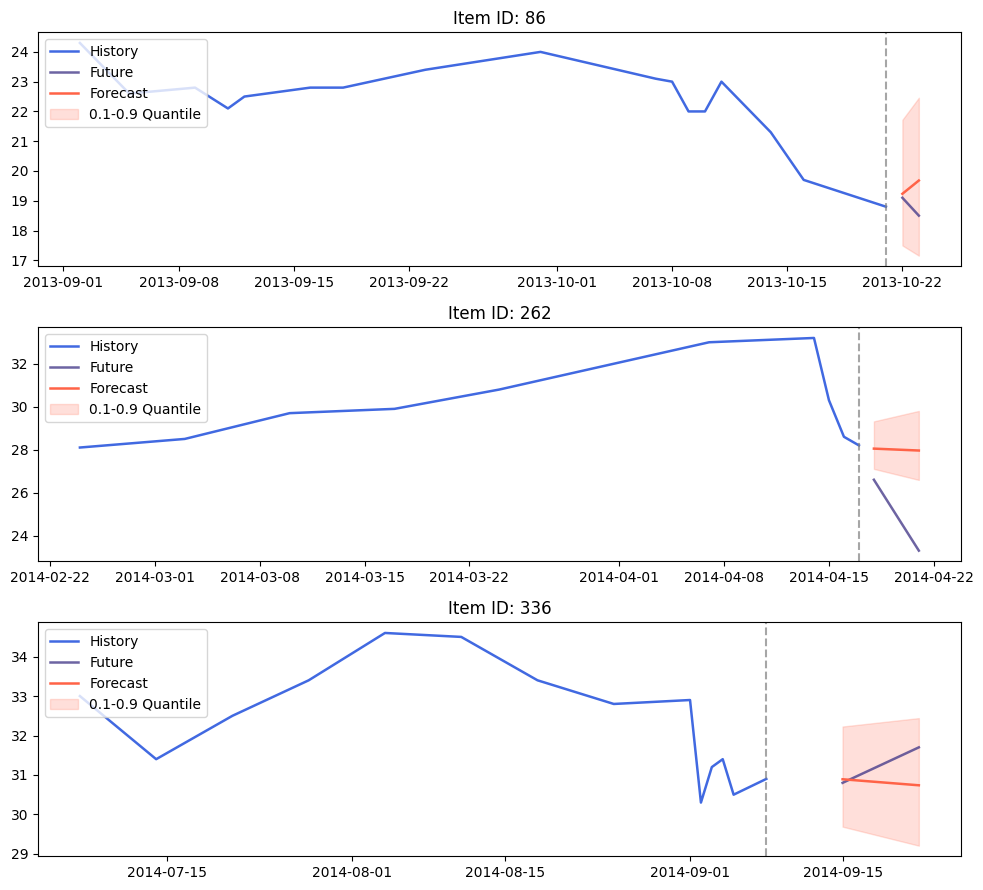

In [198]:
plot_item_ids = np.random.choice(test_df["item_id"].unique(), size=3, replace=False)
plot_forecast(
    context_df=context_df, pred_df=pred_df, test_df=test_df, item_ids=plot_item_ids
)

### Set data for self-made models

In [186]:
train_tsdf = train_tsdf.droplevel("timestamp")
test_tsdf = test_tsdf.droplevel("timestamp")

train_tsdf = train_tsdf[["id", "running_index", "intervention", "target"]]
test_tsdf = test_tsdf[["id", "running_index", "intervention", "target"]]
# train_tsdf = train_tsdf[["id", "days_since", "intervention", "target"]]
# test_tsdf = test_tsdf[["id", "days_since", "intervention", "target"]]

### Basic mouse
PFN trained on only the mouse prior.

In [187]:
MODELPATH = "/data/PFN/Mouse/Experiments/Mouse1/"
MODELFILE = "pretrained_mousepfn.pth"
MODELNAME = "MousePFN"
BUCKETNAME = "buckets_mousepfn.pth"

reg = get_model(
    model_path=MODELPATH,
    model_file=MODELFILE,
    bucket_name=BUCKETNAME
)

table_mae, table_mape = evaluate(
    model_name=MODELNAME,
    reg=reg,
    table_mae=table_mae,
    table_mape=table_mape,
    therapy_types=therapy_types,
    info_df=info_df,
    train_tsdf=train_tsdf,
    test_tsdf=test_tsdf,
    test_df=test_df,
    auto_regressive=False,
    length_boundary=None
)

0it [00:00, ?it/s]

186it [00:06, 28.59it/s]
/workspaces/nanoPFN/.venv/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/workspaces/nanoPFN/.venv/lib/python3.10/site-packages/numpy/_core/_methods.py:139: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


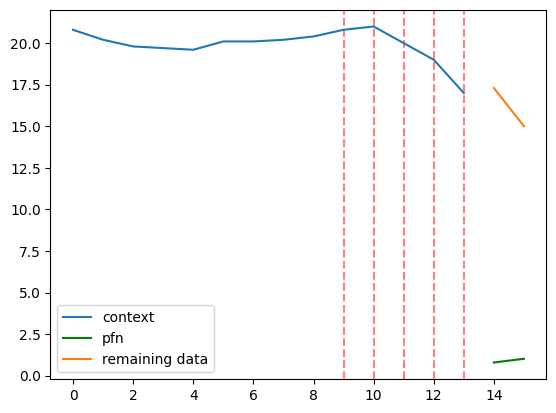

In [188]:
NUM_PLOTS = 1

mouse_ids = train_tsdf["id"].unique()
plot_mouse_ids = np.random.choice(mouse_ids, size=NUM_PLOTS, replace=False)

for id in plot_mouse_ids:
    train_x, train_y, test_x, test_y, preds = predict_mouse(
        id,
        reg,
        info_df,
        train_tsdf,
        test_tsdf,
        test_df,
        auto_regressive=False,
        length_boundary=None,
        for_plotting=True
    )

    plot_prediction(
        train_x,
        train_y,
        test_x,
        test_y,
        preds
    )

### TabPFN -> mouse
Pretrained on TabPFN prior v1 then pretrained on mouse prior.

In [189]:
MODELPATH = "/data/PFN/Mouse/Experiments/TabPFN_Mouse1/"
MODELFILE = "pretrained_mousepfn.pth"
MODELNAME = "TabPFN-MousePFN"
BUCKETNAME = "buckets_mousepfn.pth"

reg = get_model(
    model_path=MODELPATH,
    model_file=MODELFILE,
    bucket_name=BUCKETNAME
)

table_mae, table_mape = evaluate(
    model_name=MODELNAME,
    reg=reg,
    table_mae=table_mae,
    table_mape=table_mape,
    therapy_types=therapy_types,
    info_df=info_df,
    train_tsdf=train_tsdf,
    test_tsdf=test_tsdf,
    test_df=test_df,
    auto_regressive=False,
    length_boundary=None
)

0it [00:00, ?it/s]

186it [00:06, 27.74it/s]
/workspaces/nanoPFN/.venv/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/workspaces/nanoPFN/.venv/lib/python3.10/site-packages/numpy/_core/_methods.py:139: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


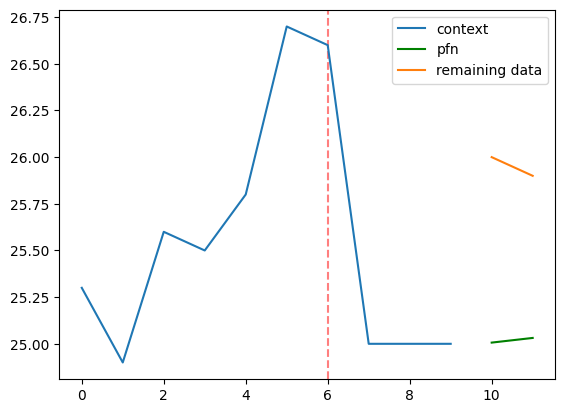

In [190]:
NUM_PLOTS = 1

mouse_ids = train_tsdf["id"].unique()
plot_mouse_ids = np.random.choice(mouse_ids, size=NUM_PLOTS, replace=False)

for id in plot_mouse_ids:
    train_x, train_y, test_x, test_y, preds = predict_mouse(
        id,
        reg,
        info_df,
        train_tsdf,
        test_tsdf,
        test_df,
        auto_regressive=False,
        length_boundary=None,
        for_plotting=True
    )

    plot_prediction(
        train_x,
        train_y,
        test_x,
        test_y,
        preds
    )

### Mouse, no context
Make the context window only contain the mouse we're predicting for. Do not add other similar mice.

In [191]:
MODELPATH = "/data/PFN/Mouse/Experiments/Mouse1/"
MODELFILE = "pretrained_mousepfn.pth"
MODELNAME = "Auto-reg MousePFN"
BUCKETNAME = "buckets_mousepfn.pth"

reg = get_model(
    model_path=MODELPATH,
    model_file=MODELFILE,
    bucket_name=BUCKETNAME
)

table_mae, table_mape = evaluate(
    model_name=MODELNAME,
    reg=reg,
    table_mae=table_mae,
    table_mape=table_mape,
    therapy_types=therapy_types,
    info_df=info_df,
    train_tsdf=train_tsdf,
    test_tsdf=test_tsdf,
    test_df=test_df,
    auto_regressive=True,
    length_boundary=None
)

0it [00:00, ?it/s]

186it [00:03, 50.14it/s]
/workspaces/nanoPFN/.venv/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/workspaces/nanoPFN/.venv/lib/python3.10/site-packages/numpy/_core/_methods.py:139: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


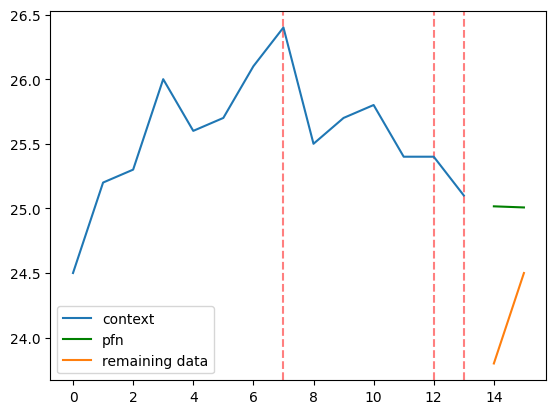

In [192]:
NUM_PLOTS = 1

mouse_ids = train_tsdf["id"].unique()
plot_mouse_ids = np.random.choice(mouse_ids, size=NUM_PLOTS, replace=False)

for id in plot_mouse_ids:
    train_x, train_y, test_x, test_y, preds = predict_mouse(
        id,
        reg,
        info_df,
        train_tsdf,
        test_tsdf,
        test_df,
        auto_regressive=True,
        length_boundary=None,
        for_plotting=True
    )

    plot_prediction(
        train_x,
        train_y,
        test_x,
        test_y,
        preds
    )

### Mouse, context for long-lived mice
Only add context when the mice has a lot of data, otherwise do it auto-regressively.

In [193]:
LENGTH_BOUNDARY = 20
MODELPATH = "/data/PFN/Mouse/Experiments/Mouse1/"
MODELFILE = "pretrained_mousepfn.pth"
MODELNAME = f"<{LENGTH_BOUNDARY} Auto-reg MousePFN"
BUCKETNAME = "buckets_mousepfn.pth"

reg = get_model(
    model_path=MODELPATH,
    model_file=MODELFILE,
    bucket_name=BUCKETNAME
)

table_mae, table_mape = evaluate(
    model_name=MODELNAME,
    reg=reg,
    table_mae=table_mae,
    table_mape=table_mape,
    therapy_types=therapy_types,
    info_df=info_df,
    train_tsdf=train_tsdf,
    test_tsdf=test_tsdf,
    test_df=test_df,
    auto_regressive=False,
    length_boundary=LENGTH_BOUNDARY
)

3it [00:00, 29.62it/s]

186it [00:03, 46.69it/s]
/workspaces/nanoPFN/.venv/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/workspaces/nanoPFN/.venv/lib/python3.10/site-packages/numpy/_core/_methods.py:139: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


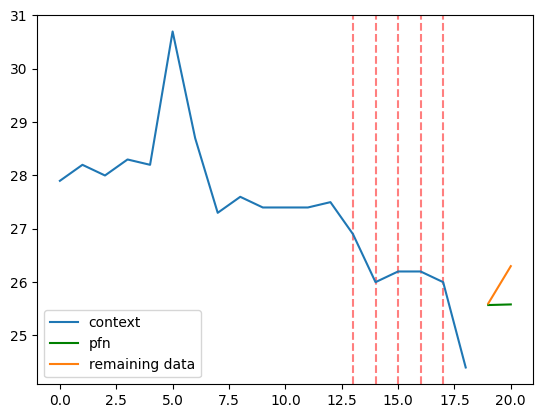

In [194]:
NUM_PLOTS = 1

mouse_ids = train_tsdf["id"].unique()
plot_mouse_ids = np.random.choice(mouse_ids, size=NUM_PLOTS, replace=False)

for id in plot_mouse_ids:
    train_x, train_y, test_x, test_y, preds = predict_mouse(
        id,
        reg,
        info_df,
        train_tsdf,
        test_tsdf,
        test_df,
        auto_regressive=False,
        length_boundary=LENGTH_BOUNDARY,
        for_plotting=True
    )

    plot_prediction(
        train_x,
        train_y,
        test_x,
        test_y,
        preds
    )

### Comparison

In [195]:
table_mae.sort_values("Overall").reset_index()

,index,Model,No treatment,Radiotherapy,Radio- and chemotherapy,Chemotherapy,Surgery,Overall
0,1,TabPFN time-series (T=1),NaN,0.853734,0.852089,0.828682,NaN,0.844835
1,0,Eagle eye (T=1),NaN,1.041000,1.434000,0.851000,NaN,1.108700
2,2,TabPFN time-series (T=2),NaN,1.538335,1.643811,1.102761,NaN,1.428302
3,9,<20 Auto-reg MousePFN (T=1),NaN,1.301067,1.714562,1.521925,NaN,1.512518
4,7,Auto-reg MousePFN (T=1),NaN,1.085662,1.987110,1.721113,NaN,1.597962
5,3,MousePFN (T=1),NaN,1.387750,2.345723,1.274738,NaN,1.669404
6,5,TabPFN-MousePFN (T=1),NaN,1.577364,3.006660,1.117989,NaN,1.900671
7,10,<20 Auto-reg MousePFN (T=2),NaN,1.921210,2.217921,1.907760,NaN,2.015630
8,8,Auto-reg MousePFN (T=2),NaN,1.801838,2.518927,1.845176,NaN,2.055314
9,4,MousePFN (T=2),NaN,1.845218,2.764221,2.192809,NaN,2.267416


In [196]:
table_mape.sort_values("Overall").reset_index()

,index,Model,No treatment,Radiotherapy,Radio- and chemotherapy,Chemotherapy,Surgery,Overall
0,1,TabPFN time-series (T=1),NaN,0.037992,0.037576,0.034269,NaN,0.036612
1,0,Eagle eye (T=1),NaN,0.049000,0.068000,0.036000,NaN,0.051000
2,2,TabPFN time-series (T=2),NaN,0.072534,0.077951,0.045930,NaN,0.065472
3,9,<20 Auto-reg MousePFN (T=1),NaN,0.058954,0.078116,0.065248,NaN,0.067439
4,7,Auto-reg MousePFN (T=1),NaN,0.048919,0.089477,0.073213,NaN,0.070536
5,3,MousePFN (T=1),NaN,0.062586,0.113166,0.055886,NaN,0.077212
6,5,TabPFN-MousePFN (T=1),NaN,0.073100,0.141435,0.048146,NaN,0.087560
7,10,<20 Auto-reg MousePFN (T=2),NaN,0.091089,0.104602,0.081023,NaN,0.092238
8,8,Auto-reg MousePFN (T=2),NaN,0.084625,0.117566,0.077811,NaN,0.093334
9,4,MousePFN (T=2),NaN,0.087003,0.136553,0.097242,NaN,0.106933


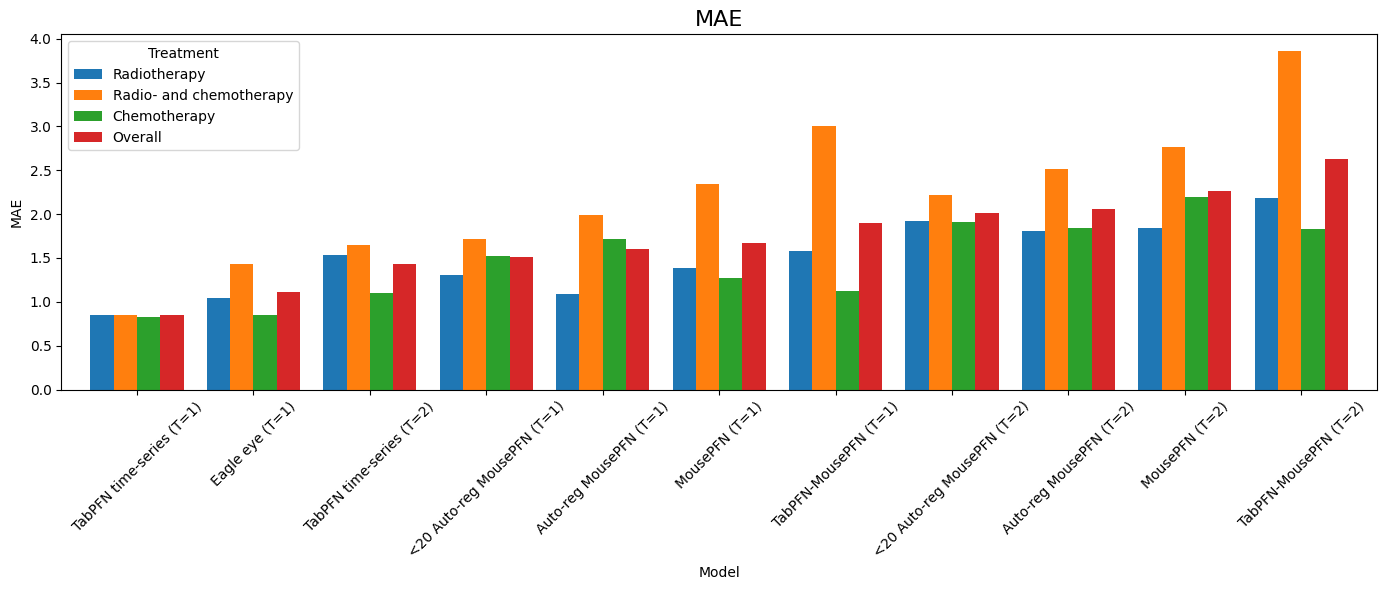

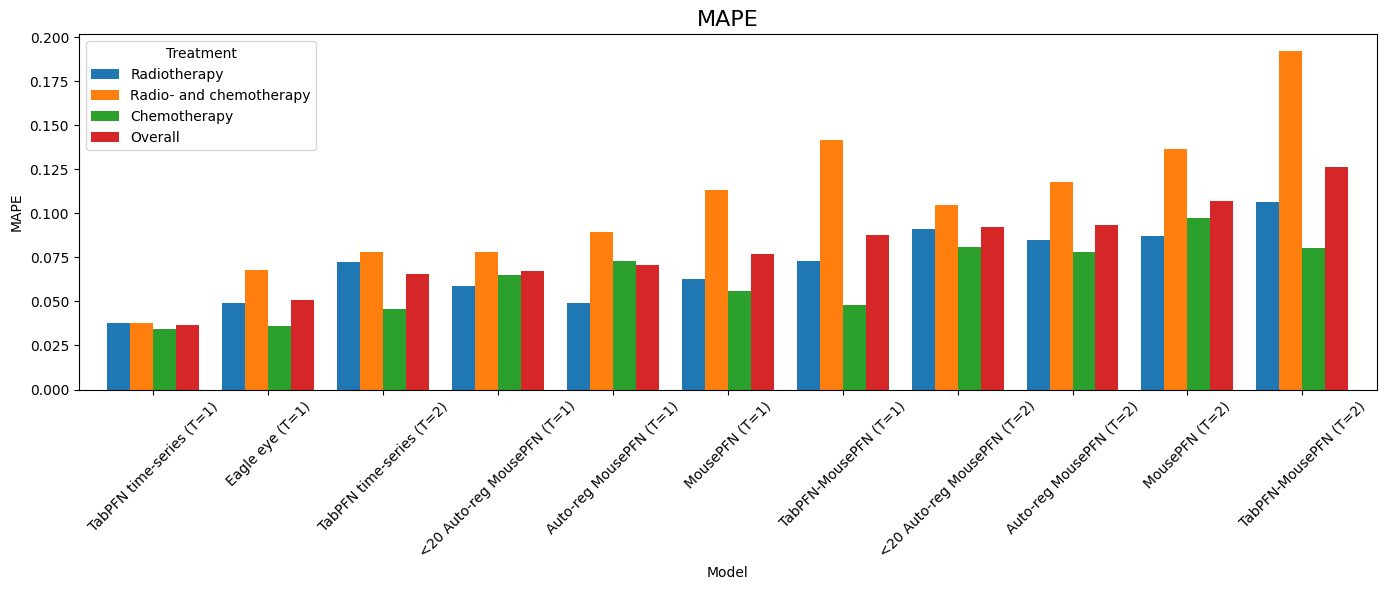

In [197]:
def plot_metric(df, metric_name):
    # Use model names as x-axis
    plot_df = df.set_index("Model").sort_values("Overall")

    # Remove columns that contain only NaNs
    plot_df = plot_df.dropna(axis=1, how="all")

    fig, ax = plt.subplots(figsize=(14, 6))

    plot_df.plot(
        kind="bar",
        ax=ax,
        width=0.8,
    )

    ax.set_title(metric_name, fontsize=16)
    ax.set_xlabel("Model")
    ax.set_ylabel(metric_name)
    ax.legend(title="Treatment")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()

    return fig, ax

# MAE plot
plot_metric(table_mae, "MAE")

# MAPE plot
plot_metric(table_mape, "MAPE")

plt.show()